# Compute the global time series

In [1]:
print('Loading packages...')
import sys
sys.path.append('../00_modules/.')
from import_packages import PackageGetter
globals().update(PackageGetter.import_standard_packages_for_analysis_and_plotting())
globals().update(PackageGetter.import_custom_packages())

Loading packages...


## 0) define functions

In [2]:
def calc_vertical_stat(da, thickness_weights, stat, mask=None, dims=None):
    if stat == 'mean':
        da_stat = SpaceOperator.calc_vertical_mean(da, thickness_weights, mask=mask, dims=dims)
    elif stat == 'integral':
        da_stat = SpaceOperator.calc_vertical_integral(da, thickness_weights, mask=mask, dims=dims)
    return da_stat

def calc_horizontal_stat(da, area_weights, stat, mask=None, dims=None,grid_cell_fractions=None):
    if stat == 'mean':
        da_stat = SpaceOperator.calc_spatial_mean(da, area_weights, mask=mask, dims=dims, grid_cell_fractions=grid_cell_fractions)
    elif stat == 'integral':
        da_stat = SpaceOperator.calc_spatial_integral(da, area_weights, mask=mask, dims=dims, grid_cell_fractions=grid_cell_fractions)
    return da_stat

def get_stat(varia,default=True):
    if default == True:
        if varia in ['tas','tos']:
            stat = 'mean'
        elif varia in ['fgco2','intpp','nbp','npp','cLand','cSoil','cVeg','cCwd','cLitter','dissic','fco2antt']:
            stat = 'integral'
        elif varia in ['co2mass']:
            stat = None
    else:
        stat = 'mean'
    return stat

def get_vert_stat(varia,default=True):
    if default == True:
        if varia in ['dissic']:
            vert_stat = 'integral'
        else:
            vert_stat = None
    else:
        vert_stat = None
    return vert_stat

## 1) get the varias, models and runs over which to do computation

In [15]:
#stat = 'integral'#'mean'
freq_input = 'monthly'#, 'yearly', 'daily'] #freq_output = 'monthly'#, 'yearly', 'daily', 'climatology', None]
varias = ['intpp','npp','tos'] # ['fgco2','nbp','cLand','dissic','cSoil','cVeg','cLitter','cCwd']#  # 'tas',                ,'co2mass']#['fgco2']#['nbp']#['nbp','cLand'] #['nbp']#['nbp']#['fco2antt']#['cLand','cSoil','cVeg','cLitter','cCwd']#['cLitter']#'cCwd',#['cLand']#['cSoil','cVeg']#['cLitter']#['cCwd']#['cSoil','cVeg']#'cLand',#['tas','nbp','npp','tos','fgco2','intpp']
models = ['NorESM2-LM']#['IPSL-CM6-ESMCO2']#['NorESM2-LM']#['GISSE2.1-G-CC2']#['EC-Earth3-ESM-1']#,'UKESM1-2']#['NorESM2-LM']#['GFDL-ESM2M']#['IPSL-CM6-ESMCO2']#['UKESM1-2']#['IPSL-CM6-ESMCO2','NorESM2-LM','GFDL-ESM2M'] # ,
runs = pruns.get_run_list('tipmip_tier1')#[:1]#[-1:]#[:1]#[:1]#[1:]#[-1:] #

outroot = './../01_postprocessed_data/global_time_series'

## 2) loop over models and runs to do the computation, plotting and saving

In [6]:
from dask.distributed import Client
client = Client()

/net/nfs/tools/u20/Python/miniconda3_py311_23.11.0-2/envs/pangeo-meso-2024.01.22/lib/python3.11/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 46777 instead
  warnings.warn(
2026-05-05 17:15:21,831 - distributed.utils_perf - WARNING - full garbage collections took 10% CPU time recently (threshold: 10%)
2026-05-05 17:15:35,332 - distributed.utils_perf - WARNING - full garbage collections took 10% CPU time recently (threshold: 10%)
2026-05-05 17:16:06,519 - distributed.utils_perf - WARNING - full garbage collections took 10% CPU time recently (threshold: 10%)
2026-05-05 17:16:25,044 - distributed.utils_perf - WARNING - full garbage collections took 10% CPU time recently (threshold: 10%)
2026-05-05 17:19:07,963 - distributed.utils_perf - WARNING - full garbage collections took 10% CPU time recently (threshold: 10%)
2026-05-05 17:19:25,069 - distributed.utils_perf - WARNING - full 

In [7]:
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:46777/status,
Dashboard: http://127.0.0.1:46777/status,Workers: 8
Total threads: 40,Total memory: 80.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:34351,Workers: 8
Dashboard: http://127.0.0.1:46777/status,Total threads: 40
Started: Just now,Total memory: 80.00 GiB
Comm: tcp://127.0.0.1:36239,Total threads: 5
Dashboard: http://127.0.0.1:33671/status,Memory: 10.00 GiB
Nanny: tcp://127.0.0.1:38473,


Processing data for intpp, NorESM2-LM, esm-piControl...
/data/ekoehn/TIPMIP/NCC/NorESM2-LM/esm-piControl/r1i1p1f1/Omon/intpp/gn/v*/intpp_*_gn_*.nc
['/data/ekoehn/TIPMIP/NCC/NorESM2-LM/esm-piControl/r1i1p1f1/Omon/intpp/gn/v20190920/intpp_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gn_185101-186012.nc', '/data/ekoehn/TIPMIP/NCC/NorESM2-LM/esm-piControl/r1i1p1f1/Omon/intpp/gn/v20190920/intpp_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gn_186101-187012.nc', '/data/ekoehn/TIPMIP/NCC/NorESM2-LM/esm-piControl/r1i1p1f1/Omon/intpp/gn/v20190920/intpp_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gn_187101-188012.nc', '/data/ekoehn/TIPMIP/NCC/NorESM2-LM/esm-piControl/r1i1p1f1/Omon/intpp/gn/v20190920/intpp_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gn_188101-189012.nc', '/data/ekoehn/TIPMIP/NCC/NorESM2-LM/esm-piControl/r1i1p1f1/Omon/intpp/gn/v20190920/intpp_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gn_189101-190012.nc', '/data/ekoehn/TIPMIP/NCC/NorESM2-LM/esm-piControl/r1i1p1f1/Omon/intpp/gn/v20190920/intpp_Omon_NorESM2-

2026-05-05 17:51:14,652 - distributed.utils_perf - WARNING - full garbage collections took 14% CPU time recently (threshold: 10%)


<xarray.DataArray 'intpp_global_integral' (time: 3000)>
array([9.96386880e+07, 9.25887600e+07, 9.21195200e+07, ...,
       9.32428720e+07, 1.05664088e+08, 1.09303064e+08], dtype=float32)
Coordinates:
  * time     (time) object 1851-01-16 12:00:00 ... 2100-12-16 12:00:00
Attributes:
    units:                mol m-2 s-1 x m2
    grid_cell_fractions:  sftlf or sftof are not considered when calculating ...
... plotting esm-piControl
 
Processing data for intpp, NorESM2-LM, esm-up2p0...
/projets/TipESM/UiB/NorESM2-LM/esm-up2p0/v*/intpp_*_gn_*.nc
['/projets/TipESM/UiB/NorESM2-LM/esm-up2p0/v20251010/intpp_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gn_185001-185912.nc', '/projets/TipESM/UiB/NorESM2-LM/esm-up2p0/v20251010/intpp_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gn_186001-186912.nc', '/projets/TipESM/UiB/NorESM2-LM/esm-up2p0/v20251010/intpp_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gn_187001-187912.nc', '/projets/TipESM/UiB/NorESM2-LM/esm-up2p0/v20251010/intpp_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gn_188001-188

2026-05-05 17:51:30,884 - distributed.utils_perf - WARNING - full garbage collections took 14% CPU time recently (threshold: 10%)


<xarray.DataArray 'intpp_global_integral' (time: 2700)>
array([99846800., 94176992., 90637880., ..., 79190504., 87925952.,
       98471224.], dtype=float32)
Coordinates:
  * time     (time) object 1850-01-16 12:00:00 ... 2074-12-16 12:00:00
Attributes:
    units:                mol m-2 s-1 x m2
    grid_cell_fractions:  sftlf or sftof are not considered when calculating ...
... plotting esm-up2p0
 
Processing data for intpp, NorESM2-LM, esm-up2p0-gwl2p0...
/projets/TipESM/UiB/NorESM2-LM/esm-up2p0-swl2p0/v*/intpp_*_gn_*.nc
['/projets/TipESM/UiB/NorESM2-LM/esm-up2p0-swl2p0/v20251009/intpp_Omon_NorESM2-LM_esm-up2p0-swl2p0_r1i1p1f1_gn_195101-195912.nc', '/projets/TipESM/UiB/NorESM2-LM/esm-up2p0-swl2p0/v20251009/intpp_Omon_NorESM2-LM_esm-up2p0-swl2p0_r1i1p1f1_gn_196001-196912.nc', '/projets/TipESM/UiB/NorESM2-LM/esm-up2p0-swl2p0/v20251009/intpp_Omon_NorESM2-LM_esm-up2p0-swl2p0_r1i1p1f1_gn_197001-197912.nc', '/projets/TipESM/UiB/NorESM2-LM/esm-up2p0-swl2p0/v20251009/intpp_Omon_NorESM2-LM_esm

2026-05-05 17:52:09,337 - distributed.utils_perf - WARNING - full garbage collections took 15% CPU time recently (threshold: 10%)


<xarray.DataArray 'intpp_global_integral' (time: 3300)>
array([84664616., 82109312., 76483848., ..., 82825840., 93231208.,
       98556544.], dtype=float32)
Coordinates:
  * time     (time) object 2057-01-16 12:00:00 ... 2331-12-16 12:00:00
Attributes:
    units:                mol m-2 s-1 x m2
    grid_cell_fractions:  sftlf or sftof are not considered when calculating ...
... plotting esm-up2p0-gwl4p0
 
Processing data for intpp, NorESM2-LM, esm-up2p0-gwl2p0-50y-dn2p0...
/projets/TipESM/UiB/NorESM2-LM/esm-up2p0-swl2p0-50y-dn2p0/v*/intpp_*_gn_*.nc
['/projets/TipESM/UiB/NorESM2-LM/esm-up2p0-swl2p0-50y-dn2p0/v20251010/intpp_Omon_NorESM2-LM_esm-up2p0-swl2p0-50y-dn2p0_r1i1p1f1_gn_200101-200912.nc', '/projets/TipESM/UiB/NorESM2-LM/esm-up2p0-swl2p0-50y-dn2p0/v20251010/intpp_Omon_NorESM2-LM_esm-up2p0-swl2p0-50y-dn2p0_r1i1p1f1_gn_201001-201912.nc', '/projets/TipESM/UiB/NorESM2-LM/esm-up2p0-swl2p0-50y-dn2p0/v20251010/intpp_Omon_NorESM2-LM_esm-up2p0-swl2p0-50y-dn2p0_r1i1p1f1_gn_202001-202912.nc

2026-05-05 17:52:53,634 - distributed.utils_perf - WARNING - full garbage collections took 18% CPU time recently (threshold: 10%)


<xarray.DataArray 'intpp_global_integral' (time: 3600)>
array([9.03933280e+07, 8.47995200e+07, 7.84059200e+07, ...,
       8.26977600e+07, 9.47529040e+07, 1.00488216e+08], dtype=float32)
Coordinates:
  * time     (time) object 2185-01-16 12:00:00 ... 2484-12-16 12:00:00
Attributes:
    units:                mol m-2 s-1 x m2
    grid_cell_fractions:  sftlf or sftof are not considered when calculating ...
... plotting esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0
 


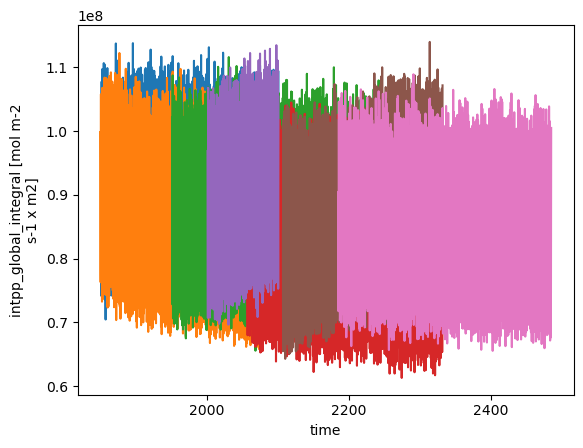

Processing data for npp, NorESM2-LM, esm-piControl...
/data/ekoehn/TIPMIP/NCC/NorESM2-LM/esm-piControl/r1i1p1f1/Lmon/npp/gn/v*/npp_*_gn_*.nc
['/data/ekoehn/TIPMIP/NCC/NorESM2-LM/esm-piControl/r1i1p1f1/Lmon/npp/gn/v20190920/npp_Lmon_NorESM2-LM_esm-piControl_r1i1p1f1_gn_185101-186012.nc', '/data/ekoehn/TIPMIP/NCC/NorESM2-LM/esm-piControl/r1i1p1f1/Lmon/npp/gn/v20190920/npp_Lmon_NorESM2-LM_esm-piControl_r1i1p1f1_gn_186101-187012.nc', '/data/ekoehn/TIPMIP/NCC/NorESM2-LM/esm-piControl/r1i1p1f1/Lmon/npp/gn/v20190920/npp_Lmon_NorESM2-LM_esm-piControl_r1i1p1f1_gn_187101-188012.nc', '/data/ekoehn/TIPMIP/NCC/NorESM2-LM/esm-piControl/r1i1p1f1/Lmon/npp/gn/v20190920/npp_Lmon_NorESM2-LM_esm-piControl_r1i1p1f1_gn_188101-189012.nc', '/data/ekoehn/TIPMIP/NCC/NorESM2-LM/esm-piControl/r1i1p1f1/Lmon/npp/gn/v20190920/npp_Lmon_NorESM2-LM_esm-piControl_r1i1p1f1_gn_189101-190012.nc', '/data/ekoehn/TIPMIP/NCC/NorESM2-LM/esm-piControl/r1i1p1f1/Lmon/npp/gn/v20190920/npp_Lmon_NorESM2-LM_esm-piControl_r1i1p1f1_gn_1

2026-05-05 17:53:17,427 - distributed.utils_perf - WARNING - full garbage collections took 18% CPU time recently (threshold: 10%)


<xarray.DataArray 'npp_global_integral' (time: 2699)>
array([1268201.5, 1345867.2, 1528069.2, ..., 2437618.8, 2272065.8,
       2099231.5], dtype=float32)
Coordinates:
  * time     (time) object 1850-02-15 00:00:00 ... 2074-12-16 12:00:00
Attributes:
    units:                kg m-2 s-1 x m2
    grid_cell_fractions:  sftlf or sftof are not considered when calculating ...
... plotting esm-up2p0
 
Processing data for npp, NorESM2-LM, esm-up2p0-gwl2p0...
/projets/TipESM/UiB/NorESM2-LM/esm-up2p0-swl2p0/v*/npp_*_gn_*.nc
['/projets/TipESM/UiB/NorESM2-LM/esm-up2p0-swl2p0/v20251009/npp_Lmon_NorESM2-LM_esm-up2p0-swl2p0_r1i1p1f1_gn_195101-195912.nc', '/projets/TipESM/UiB/NorESM2-LM/esm-up2p0-swl2p0/v20251009/npp_Lmon_NorESM2-LM_esm-up2p0-swl2p0_r1i1p1f1_gn_196001-196912.nc', '/projets/TipESM/UiB/NorESM2-LM/esm-up2p0-swl2p0/v20251009/npp_Lmon_NorESM2-LM_esm-up2p0-swl2p0_r1i1p1f1_gn_197001-197912.nc', '/projets/TipESM/UiB/NorESM2-LM/esm-up2p0-swl2p0/v20251009/npp_Lmon_NorESM2-LM_esm-up2p0-swl2p0_r

2026-05-05 17:53:39,988 - distributed.utils_perf - WARNING - full garbage collections took 18% CPU time recently (threshold: 10%)


<xarray.DataArray 'npp_global_integral' (time: 3300)>
array([2293912. , 2406557.2, 2635417. , ..., 2590580.2, 2123115.8,
       2143545.2], dtype=float32)
Coordinates:
  * time     (time) object 2057-01-16 12:00:00 ... 2331-12-16 12:00:00
Attributes:
    units:                kg m-2 s-1 x m2
    grid_cell_fractions:  sftlf or sftof are not considered when calculating ...
... plotting esm-up2p0-gwl4p0
 
Processing data for npp, NorESM2-LM, esm-up2p0-gwl2p0-50y-dn2p0...
/projets/TipESM/UiB/NorESM2-LM/esm-up2p0-swl2p0-50y-dn2p0/v*/npp_*_gn_*.nc
['/projets/TipESM/UiB/NorESM2-LM/esm-up2p0-swl2p0-50y-dn2p0/v20251010/npp_Lmon_NorESM2-LM_esm-up2p0-swl2p0-50y-dn2p0_r1i1p1f1_gn_200101-200912.nc', '/projets/TipESM/UiB/NorESM2-LM/esm-up2p0-swl2p0-50y-dn2p0/v20251010/npp_Lmon_NorESM2-LM_esm-up2p0-swl2p0-50y-dn2p0_r1i1p1f1_gn_201001-201912.nc', '/projets/TipESM/UiB/NorESM2-LM/esm-up2p0-swl2p0-50y-dn2p0/v20251010/npp_Lmon_NorESM2-LM_esm-up2p0-swl2p0-50y-dn2p0_r1i1p1f1_gn_202001-202912.nc', '/projets/

2026-05-05 17:53:55,804 - distributed.utils_perf - WARNING - full garbage collections took 17% CPU time recently (threshold: 10%)


<xarray.DataArray 'npp_global_integral' (time: 2700)>
array([2251200.2 , 2417194.  , 2654423.  , ...,  774532.75,  723841.56,
        729760.44], dtype=float32)
Coordinates:
  * time     (time) object 2107-01-16 12:00:00 ... 2331-12-16 12:00:00
Attributes:
    units:                kg m-2 s-1 x m2
    grid_cell_fractions:  sftlf or sftof are not considered when calculating ...
... plotting esm-up2p0-gwl4p0-50y-dn2p0
 
Processing data for npp, NorESM2-LM, esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0...
/projets/TipESM/UiB/NorESM2-LM/esm-up2p0-swl4p0-50y-dn2p0-swl2p0/v*/npp_*_gn_*.nc
['/projets/TipESM/UiB/NorESM2-LM/esm-up2p0-swl4p0-50y-dn2p0-swl2p0/v20251010/npp_Lmon_NorESM2-LM_esm-up2p0-swl4p0-50y-dn2p0-swl2p0_r1i1p1f1_gn_218501-218912.nc', '/projets/TipESM/UiB/NorESM2-LM/esm-up2p0-swl4p0-50y-dn2p0-swl2p0/v20251010/npp_Lmon_NorESM2-LM_esm-up2p0-swl4p0-50y-dn2p0-swl2p0_r1i1p1f1_gn_219001-219912.nc', '/projets/TipESM/UiB/NorESM2-LM/esm-up2p0-swl4p0-50y-dn2p0-swl2p0/v20251010/npp_Lmon_NorESM2-LM_esm

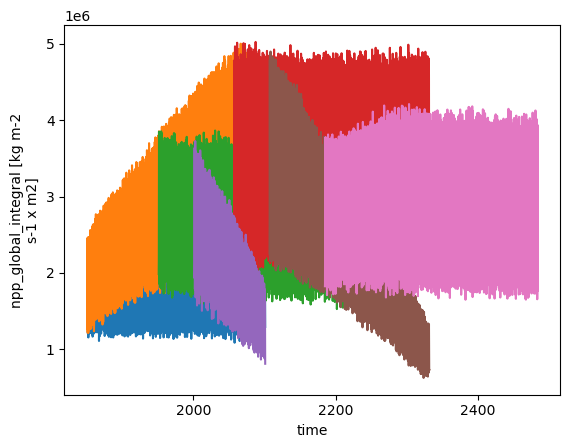

Processing data for tos, NorESM2-LM, esm-piControl...
/data/ekoehn/TIPMIP/NCC/NorESM2-LM/esm-piControl/r1i1p1f1/Omon/tos/gn/v*/tos_*_gn_*.nc
['/data/ekoehn/TIPMIP/NCC/NorESM2-LM/esm-piControl/r1i1p1f1/Omon/tos/gn/v20190920/tos_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gn_185101-186012.nc', '/data/ekoehn/TIPMIP/NCC/NorESM2-LM/esm-piControl/r1i1p1f1/Omon/tos/gn/v20190920/tos_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gn_186101-187012.nc', '/data/ekoehn/TIPMIP/NCC/NorESM2-LM/esm-piControl/r1i1p1f1/Omon/tos/gn/v20190920/tos_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gn_187101-188012.nc', '/data/ekoehn/TIPMIP/NCC/NorESM2-LM/esm-piControl/r1i1p1f1/Omon/tos/gn/v20190920/tos_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gn_188101-189012.nc', '/data/ekoehn/TIPMIP/NCC/NorESM2-LM/esm-piControl/r1i1p1f1/Omon/tos/gn/v20190920/tos_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gn_189101-190012.nc', '/data/ekoehn/TIPMIP/NCC/NorESM2-LM/esm-piControl/r1i1p1f1/Omon/tos/gn/v20190920/tos_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gn_1

2026-05-05 17:54:26,991 - distributed.utils_perf - WARNING - full garbage collections took 17% CPU time recently (threshold: 10%)


<xarray.DataArray 'tos_global_mean' (time: 3000)>
array([18.991024, 19.148018, 19.0771  , ..., 18.118591, 18.122454,
       18.270584], dtype=float32)
Coordinates:
  * time     (time) object 1851-01-16 12:00:00 ... 2100-12-16 12:00:00
Attributes:
    units:                degC
    grid_cell_fractions:  sftlf or sftof are not considered when calculating ...
... plotting esm-piControl
 
Processing data for tos, NorESM2-LM, esm-up2p0...
/projets/TipESM/UiB/NorESM2-LM/esm-up2p0/v*/tos_*_gn_*.nc
['/projets/TipESM/UiB/NorESM2-LM/esm-up2p0/v20251010/tos_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gn_185001-185912.nc', '/projets/TipESM/UiB/NorESM2-LM/esm-up2p0/v20251010/tos_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gn_186001-186912.nc', '/projets/TipESM/UiB/NorESM2-LM/esm-up2p0/v20251010/tos_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gn_187001-187912.nc', '/projets/TipESM/UiB/NorESM2-LM/esm-up2p0/v20251010/tos_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gn_188001-188912.nc', '/projets/TipESM/UiB/NorESM2-LM/esm-up2p0/v20251010

2026-05-05 17:54:51,744 - distributed.utils_perf - WARNING - full garbage collections took 17% CPU time recently (threshold: 10%)


<xarray.DataArray 'tos_global_mean' (time: 2700)>
array([18.986433, 19.156424, 19.112165, ..., 21.601158, 21.470587,
       21.61172 ], dtype=float32)
Coordinates:
  * time     (time) object 1850-01-16 12:00:00 ... 2074-12-16 12:00:00
Attributes:
    units:                degC
    grid_cell_fractions:  sftlf or sftof are not considered when calculating ...
... plotting esm-up2p0
 
Processing data for tos, NorESM2-LM, esm-up2p0-gwl2p0...
/projets/TipESM/UiB/NorESM2-LM/esm-up2p0-swl2p0/v*/tos_*_gn_*.nc
['/projets/TipESM/UiB/NorESM2-LM/esm-up2p0-swl2p0/v20251009/tos_Omon_NorESM2-LM_esm-up2p0-swl2p0_r1i1p1f1_gn_195101-195912.nc', '/projets/TipESM/UiB/NorESM2-LM/esm-up2p0-swl2p0/v20251009/tos_Omon_NorESM2-LM_esm-up2p0-swl2p0_r1i1p1f1_gn_196001-196912.nc', '/projets/TipESM/UiB/NorESM2-LM/esm-up2p0-swl2p0/v20251009/tos_Omon_NorESM2-LM_esm-up2p0-swl2p0_r1i1p1f1_gn_197001-197912.nc', '/projets/TipESM/UiB/NorESM2-LM/esm-up2p0-swl2p0/v20251009/tos_Omon_NorESM2-LM_esm-up2p0-swl2p0_r1i1p1f1_gn_1980

...

<xarray.DataArray 'tos_global_mean' (time: 1200)>
array([19.988209, 20.132442, 20.092949, ..., 18.53571 , 18.54212 ,
       18.768377], dtype=float32)
Coordinates:
  * time     (time) object 2001-01-16 12:00:00 ... 2100-12-16 12:00:00
Attributes:
    units:                degC
    grid_cell_fractions:  sftlf or sftof are not considered when calculating ...
... plotting esm-up2p0-gwl2p0-50y-dn2p0
 
Processing data for tos, NorESM2-LM, esm-up2p0-gwl4p0-50y-dn2p0...
/projets/TipESM/UiB/NorESM2-LM/esm-up2p0-swl4p0-50y-dn2p0/v*/tos_*_gn_*.nc
['/projets/TipESM/UiB/NorESM2-LM/esm-up2p0-swl4p0-50y-dn2p0/v20251015/tos_Omon_NorESM2-LM_esm-up2p0-swl4p0-50y-dn2p0_r1i1p1f1_gn_210701-210912.nc', '/projets/TipESM/UiB/NorESM2-LM/esm-up2p0-swl4p0-50y-dn2p0/v20251015/tos_Omon_NorESM2-LM_esm-up2p0-swl4p0-50y-dn2p0_r1i1p1f1_gn_211001-211912.nc', '/projets/TipESM/UiB/NorESM2-LM/esm-up2p0-swl4p0-50y-dn2p0/v20251015/tos_Omon_NorESM2-LM_esm-up2p0-swl4p0-50y-dn2p0_r1i1p1f1_gn_212001-212912.nc', '/projets/TipES

2026-05-05 17:56:24,189 - distributed.utils_perf - WARNING - full garbage collections took 15% CPU time recently (threshold: 10%)


... saving under ./../01_postprocessed_data/global_time_series/tos/NorESM2-LM/esm-up2p0-gwl4p0-50y-dn2p0/r1i1p1f1/monthly/global_mean/tos_NorESM2-LM_esm-up2p0-gwl4p0-50y-dn2p0_r1i1p1f1_global_mean.nc
<xarray.DataArray 'tos_global_mean' (time: 2700)>
array([21.758093, 21.907354, 21.852295, ..., 18.507883, 18.50343 ,
       18.71929 ], dtype=float32)
Coordinates:
  * time     (time) object 2107-01-16 12:00:00 ... 2331-12-16 12:00:00
Attributes:
    units:                degC
    grid_cell_fractions:  sftlf or sftof are not considered when calculating ...
... plotting esm-up2p0-gwl4p0-50y-dn2p0
 
Processing data for tos, NorESM2-LM, esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0...
/projets/TipESM/UiB/NorESM2-LM/esm-up2p0-swl4p0-50y-dn2p0-swl2p0/v*/tos_*_gn_*.nc
['/projets/TipESM/UiB/NorESM2-LM/esm-up2p0-swl4p0-50y-dn2p0-swl2p0/v20251010/tos_Omon_NorESM2-LM_esm-up2p0-swl4p0-50y-dn2p0-swl2p0_r1i1p1f1_gn_218501-218912.nc', '/projets/TipESM/UiB/NorESM2-LM/esm-up2p0-swl4p0-50y-dn2p0-swl2p0/v20251010/tos_O

2026-05-05 17:56:51,596 - distributed.utils_perf - WARNING - full garbage collections took 14% CPU time recently (threshold: 10%)


<xarray.DataArray 'tos_global_mean' (time: 3600)>
array([20.52739 , 20.607176, 20.56675 , ..., 20.879883, 20.82948 ,
       20.972754], dtype=float32)
Coordinates:
  * time     (time) object 2185-01-16 12:00:00 ... 2484-12-16 12:00:00
Attributes:
    units:                degC
    grid_cell_fractions:  sftlf or sftof are not considered when calculating ...
... plotting esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0
 


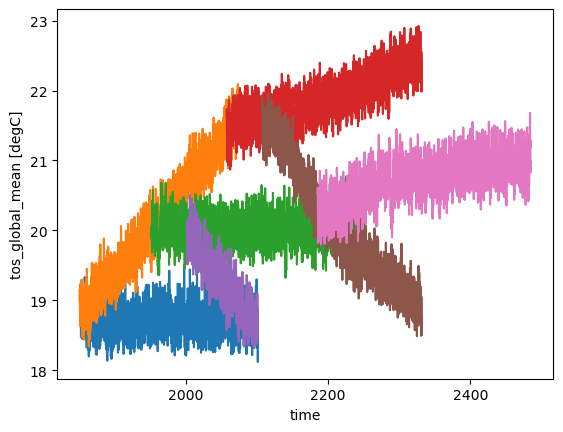

In [16]:
for varia in varias:
    stat = get_stat(varia,default=True)
    vert_stat = get_vert_stat(varia,default=True)
    for model in models:
        mgrab = MODELgrabber.get_grabber(model)
        member = mgrab.get_member()
        domain = mgrab.get_domain(varia,freq_input)

        global_stats = dict()
        for run in runs:
            print(f'Processing data for {varia}, {model}, {run}...')
            
            # first get the dataset
            da = mgrab.get_data(varia,run,freq_input=freq_input,verbose_level=1)
            print(f'... loading {da.time.size} data points in time.')
        
            # =====================================================
            # OPTIONAL VERTICAL STAT
            # =====================================================
            if vert_stat is not None:
                da = da.chunk({"time": 12,"lev": -1})#,"i": -1,"j": -1})
                print(da)
                
                print('... get thickness weights')

                if model == 'NorESM2-LM':
                    thickness_weights = mgrab.get_thickness(
                        'thkcello',freq_input)
                    thickness_weights = thickness_weights.chunk({"lev": -1})#,"i": -1,"j": -1})
                else:
                    thickness_weights = mgrab.get_data(
                        'thkcello', run, freq_input=freq_input, verbose_level=1)
                    thickness_weights = thickness_weights.chunk({"time": 12,"lev": -1})#,"i": -1,"j": -1})
                print(thickness_weights)
                
                print('... compute vertical statistic')
                da_for_horiz = calc_vertical_stat(
                    da,
                    thickness_weights,
                    vert_stat,
                    mask=None,
                    dims=None
                )
                da_for_horiz.name = f"{varia}_vertical_{vert_stat}"
                da_for_horiz = da_for_horiz.persist()
            else:
                da_for_horiz = da

            # =====================================================
            # HORIZONTAL STAT (on correct input)
            # =====================================================
            
            if stat is not None:
                # get the area_weights
                print(f'... getting area weights.')
                area_weights = mgrab.get_area(varia,freq_input)
                
                # which region do i want to cover
                #print(f'... getting a regional mask.') 
                
                #if varia in ['nbp','cLand']:
                print('getting land area fraction if necessary')
                grid_cell_fractions = mgrab.get_area_fraction(varia)
                #else:
                #    grid_cell_fractions = None

                print('... compute horizontal statistic')
                global_stat = calc_horizontal_stat(
                    da_for_horiz,   # <-- key line
                    area_weights,
                    stat,
                    mask=None,
                    dims=None,
                    grid_cell_fractions=grid_cell_fractions,
                )
            else:
                grid_cell_fractions = mgrab.get_area_fraction(varia) # not directly used, but required for writing some attributes later on
                global_stat = da_for_horiz

            # make sure that the time has uniform axis
            global_stat = TimeOperator.adjust_time_axis(global_stat) 

            # =====================================================
            # NAMING (clean + consistent)
            # =====================================================
            name_parts = [varia]
            if vert_stat is not None:
                name_parts.append(f"vertical_{vert_stat}")
            name_parts.append(f"global_{stat}")
            global_stat.name = "_".join(name_parts)

            
            # update the unit
            if stat == 'integral' and vert_stat is None:
                unit = f'{da.units} x m2'
            elif stat == 'integral' and vert_stat == 'integral':
                unit = f'{da.units} x m x m2'
            elif stat == 'integral' and vert_stat == 'mean':
                unit = f'{da.units} x m2'      
            elif stat == 'mean' and vert_stat is None:
                unit = f'{da.units}'
            elif stat == 'mean' and vert_stat == 'integral':
                unit = f'{da.units} x m'
            elif stat == 'mean' and vert_stat == 'mean':
                unit = f'{da.units}'    
            else:
                unit = da.units
            global_stat.attrs["units"] = unit

            if grid_cell_fractions is not None:
                global_stat.attrs["grid_cell_fractions"] = f"Calculating the global {stat} for {varia} scales coastal points by their cell fractions."
            else:
                global_stat.attrs["grid_cell_fractions"] = f"sftlf or sftof are not considered when calculating {varia} {stat}."
            
            # save the data
            if vert_stat is None:
                infix = ''
            else:
                infix = f'vertical_{vert_stat}_'
            save_dir = f'{outroot}/{varia}/{model}/{run}/{member}/{freq_input}/{infix}global_{stat}'
            os.makedirs(save_dir,exist_ok=True)
            save_string = f'{save_dir}/{varia}_{model}_{run}_{member}_{infix}global_{stat}.nc'
            print(f'... saving under {save_string}')

            global_stat = global_stat.compute()

            print(global_stat)
            #encoding = {global_stat.name: {"dtype": "float32", "zlib": True, "complevel": 4}}
            global_stat.to_netcdf(save_string, mode="w")#,encoding=encoding)

            # keep in a local dictionary for plotting
            global_stats[run] = global_stat

            #for key in global_stats.keys():
            print(f'... plotting {run}')
            global_stats[run].plot()
            print(' ')

        plt.show()


## 3) Plot the time series

... plotting esm-piControl ...
... plotting esm-up2p0 ...
... plotting esm-up2p0-gwl2p0 ...
... plotting esm-up2p0-gwl4p0 ...
... plotting esm-up2p0-gwl2p0-50y-dn2p0 ...
... plotting esm-up2p0-gwl4p0-50y-dn2p0 ...
... plotting esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0 ...


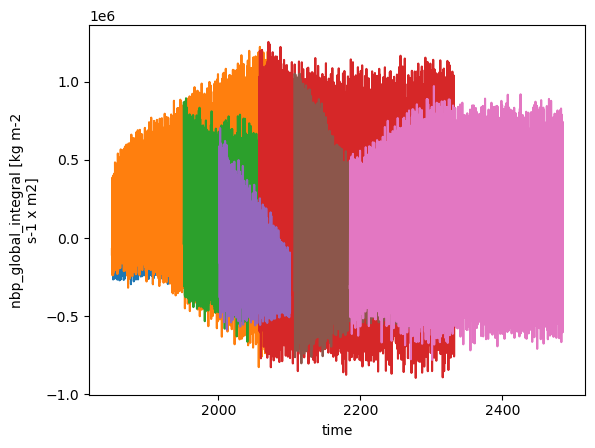

In [5]:
for key in global_stats.keys():
    print(f'... plotting {key} ...')
    global_stats[key].plot()
plt.show()